<a href="https://colab.research.google.com/github/navyasri-6/E-commerce-Segmentation/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#dataset creation
import pandas as pd
import numpy as np

np.random.seed(42)

data = pd.DataFrame({
    "CustomerID": range(1, 201),
    "Gender": np.random.choice(["Male", "Female"], 200),
    "Age": np.random.randint(18, 60, 200),
    "Annual Income (k$)": np.random.randint(15, 100, 200),
    "Spending Score (1-100)": np.random.randint(1, 100, 200)
})

data.to_csv("Mall_Customers.csv", index=False)

print("Dataset created successfully!")
print(data.head())


Dataset created successfully!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  46                      58
1           2  Female   56                  61                      39
2           3    Male   49                  37                      14
3           4    Male   21                  80                      95
4           5    Male   47                  41                       5


In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
#Load Dataset
data = pd.read_csv("Mall_Customers.csv")  # change file name if needed
print(data.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  46                      58
1           2  Female   56                  61                      39
2           3    Male   49                  37                      14
3           4    Male   21                  80                      95
4           5    Male   47                  41                       5


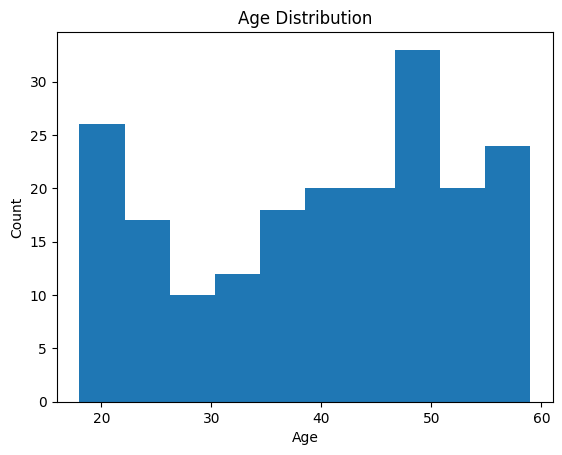

In [ ]:
#Histogram (Age Distribution)
plt.figure()
plt.hist(data['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


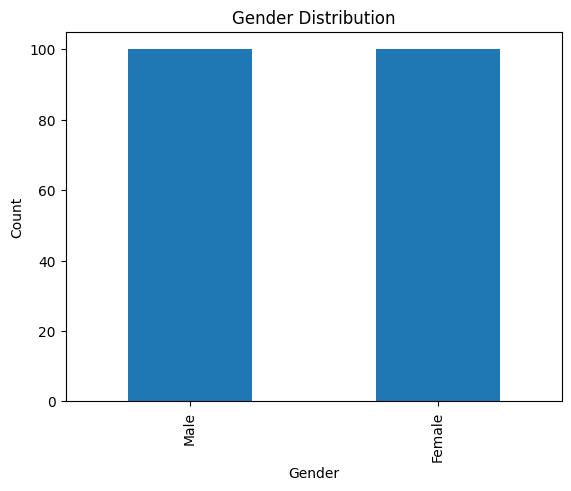

In [ ]:
#Bar Chart (Gender Distribution)
plt.figure()
data['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


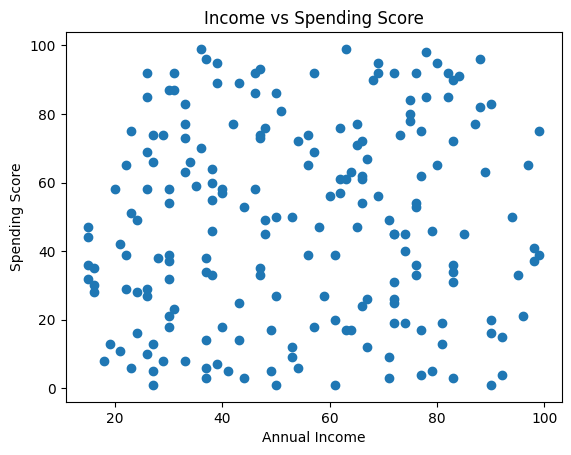

In [ ]:
#Scatter Plot (Income vs Spending Score)
plt.figure()
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()


In [ ]:
#Data Preprocessing (Scaling)
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


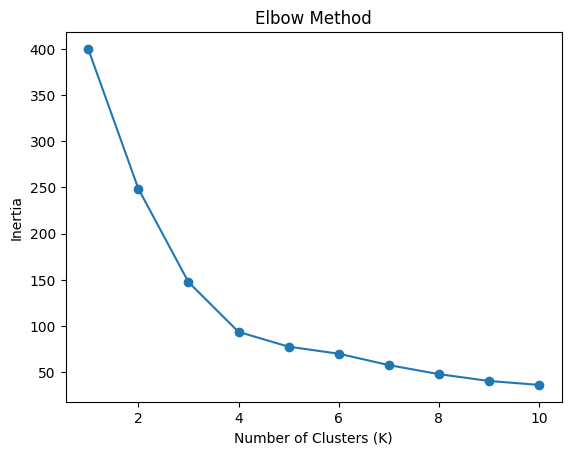

In [ ]:
#Elbow Method Graph
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [ ]:
#K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)


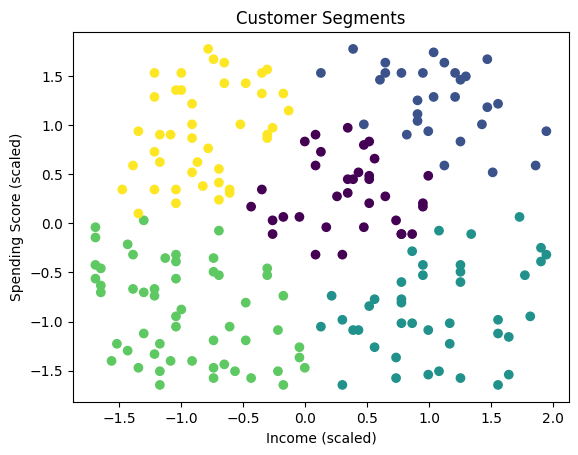

In [ ]:
#Cluster Visualization
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=data['Cluster'])
plt.title("Customer Segments")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()


In [ ]:
#Train Classification Model
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, data['Cluster'], test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


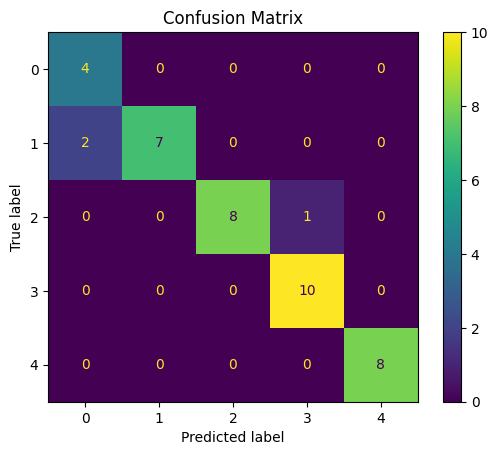

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.925


In [ ]:
#Predict New Customer
new_customer = [[50, 60]]  # income, spending score
new_customer_scaled = scaler.transform(new_customer)

prediction = model.predict(new_customer_scaled)
print("Predicted Cluster:", prediction[0])


Predicted Cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
